<a href="https://colab.research.google.com/github/MartaPCastillo/Tesis/blob/main/Grupo_Mexico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import yfinance as yf # Para descargar datos de acciones
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

#Grupo México

In [2]:
#Obtener datos
df = yf.download('GMEXICOB.MX', start='2024-01-01')

/tmp/ipykernel_4948/2329736698.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('GMEXICOB.MX', start='2024-01-01')
[*********************100%***********************]  1 of 1 completed


In [3]:
print(type(df['Close']))

<class 'pandas.core.frame.DataFrame'>


In [4]:
# Eliminar nivel del ticker
df.columns = df.columns.droplevel(1)

#Análisis de la serie

##Medias Móviles

###Media Móvil Simple

In [12]:
#Calcular Media Móvil Simple de 200 días
df['SMA200'] = df['Close'].rolling(window=200).mean()

<Axes: xlabel='Date'>

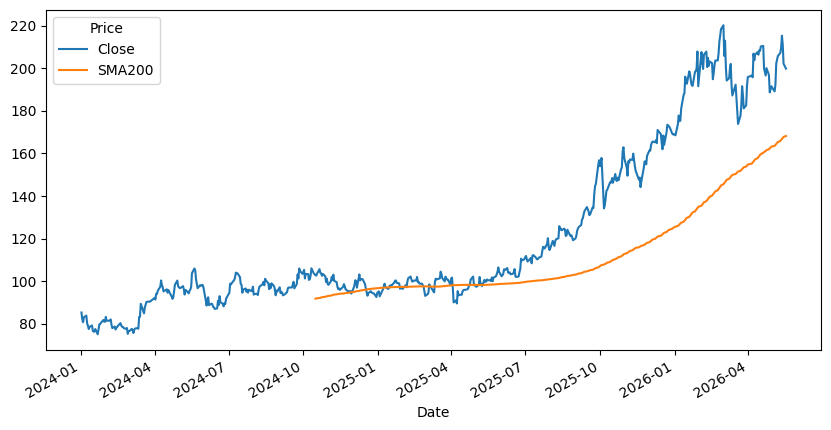

In [13]:
#Visualizar
df[['Close', 'SMA200']].plot(figsize=(10,5))

###Media Móvil Exponencial

In [14]:
#Calcular Media Móvil Exponencial de 200 días
df['EMA200'] = df['Close'].ewm(span=200, adjust=False).mean()

In [15]:
#Calcular Media Móvil Exponencial de 20 días
df['EMA20'] = df['Close'].ewm(span=20, adjust=False).mean()

<Axes: xlabel='Date'>

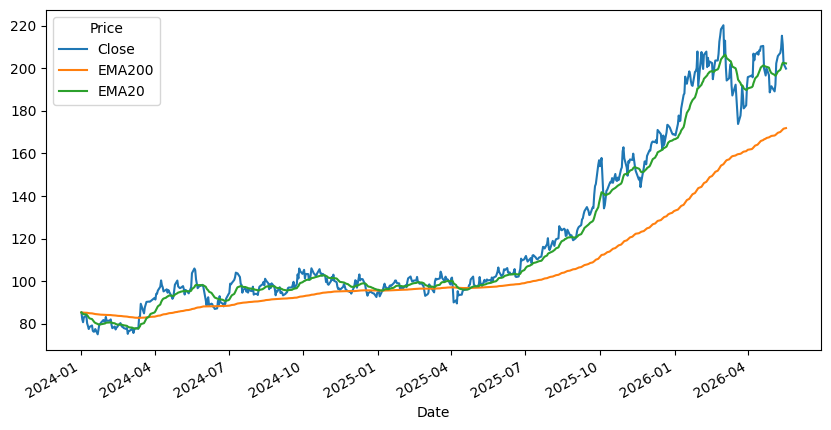

In [16]:
#Visualizar
df[['Close', 'EMA200', 'EMA20']].plot(figsize=(10,5))

##Descomposición Serie Temporal

###Modelo Aditivo

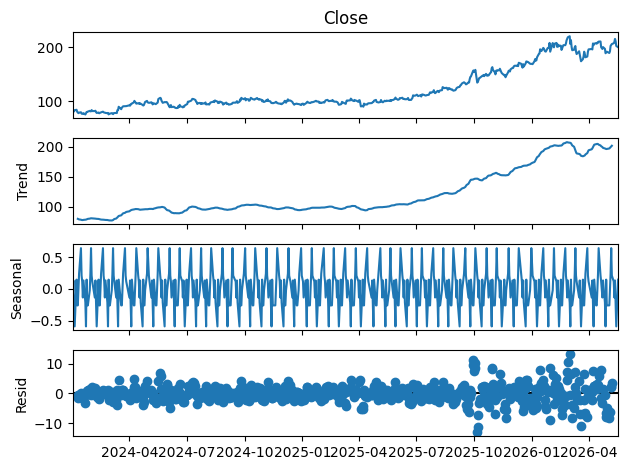

In [17]:
# Descomponer
result = seasonal_decompose(df['Close'], model='additive', period=12) # 12 meses en un año
result.plot()
plt.show()

###Modelo Multiplicativo

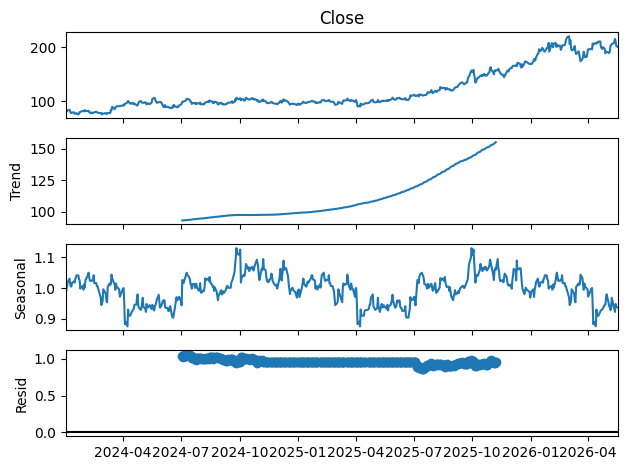

In [18]:
# Descomponer
result = seasonal_decompose(df['Close'], model='multiplicative', period=252) # 252 días hábiles en un año
result.plot()
plt.show()

#Volatilidad

##Desviación Estándar

In [19]:
#Obtener datos
precios = df['Close']

In [20]:
# Método financiero estándar para rendimientos logarítmicos
df['Rendimientos_Log'] = np.log(precios / precios.shift(1))
print(df['Rendimientos_Log'])

Date
2024-01-02         NaN
2024-01-03   -0.037720
2024-01-04   -0.017483
2024-01-05    0.028422
2024-01-08    0.009406
                ...   
2026-05-12    0.010707
2026-05-13    0.027368
2026-05-14   -0.019756
2026-05-15   -0.043095
2026-05-18   -0.011546
Name: Rendimientos_Log, Length: 593, dtype: float64


In [21]:
#Eliminar NaN solo de rendimientos
df.dropna(subset=['Rendimientos_Log'], inplace=True)
print(df['Rendimientos_Log'])

Date
2024-01-03   -0.037720
2024-01-04   -0.017483
2024-01-05    0.028422
2024-01-08    0.009406
2024-01-09   -0.044407
                ...   
2026-05-12    0.010707
2026-05-13    0.027368
2026-05-14   -0.019756
2026-05-15   -0.043095
2026-05-18   -0.011546
Name: Rendimientos_Log, Length: 592, dtype: float64


In [22]:
#Calcular la desviación estándar de los rendimientos (Volatilidad Diaria)
volatilidad_diaria = df['Rendimientos_Log'].std()

In [23]:
#Anualizar la volatilidad (multiplicando por la raíz cuadrada de 252 días hábiles al año)
volatilidad_anual = volatilidad_diaria * np.sqrt(252)

In [36]:
Volatilidad_diaria_porcentaje = volatilidad_diaria * 100
Volatilidad_anual_porcentaje = volatilidad_anual * 100

In [37]:
print(f"Volatilidad diaria: {volatilidad_diaria:.4f} = {Volatilidad_diaria_porcentaje:.4f} %")
print(f"Volatilidad anualizada: {volatilidad_anual:.4f} = {Volatilidad_anual_porcentaje:.4f} %")

Volatilidad diaria: 0.0224 = 2.2360 %
Volatilidad anualizada: 0.3549 = 35.4949 %


##Average True Range

In [38]:
#Calcular los 3 componentes del True Range (TR)
high_low = df['High'] - df['Low']
high_close = np.abs(df['High'] - df['Close'].shift(1))
low_close = np.abs(df['Low'] - df['Close'].shift(1))

In [39]:
print(high_low)

Date
2024-01-03    3.840465
2024-01-04    2.663695
2024-01-05    6.431180
2024-01-08    2.590722
2024-01-09    4.232723
                ...   
2026-05-12    7.500000
2026-05-13    8.759995
2026-05-14    8.309998
2026-05-15    8.399994
2026-05-18    8.630005
Length: 592, dtype: float64


In [40]:
print(high_close)

Date
2024-01-03         NaN
2024-01-04    0.118597
2024-01-05    6.093650
2024-01-08    0.893977
2024-01-09    0.255434
                ...   
2026-05-12    3.330002
2026-05-13    6.600006
2026-05-14    1.289993
2026-05-15    3.600006
2026-05-18    2.699997
Length: 592, dtype: float64


In [41]:
print(low_close)

Date
2024-01-03          NaN
2024-01-04     2.545098
2024-01-05     0.337530
2024-01-08     1.696744
2024-01-09     3.977289
                ...    
2026-05-12     4.169998
2026-05-13     2.159988
2026-05-14     7.020004
2026-05-15    12.000000
2026-05-18     5.930008
Length: 592, dtype: float64


In [42]:
#Unir y obtener el máximo de los 3 para cada día
ranges = pd.concat([high_low, high_close, low_close], axis=1)
true_range = ranges.max(axis=1)

In [43]:
print(true_range)

Date
2024-01-03     3.840465
2024-01-04     2.663695
2024-01-05     6.431180
2024-01-08     2.590722
2024-01-09     4.232723
                ...    
2026-05-12     7.500000
2026-05-13     8.759995
2026-05-14     8.309998
2026-05-15    12.000000
2026-05-18     8.630005
Length: 592, dtype: float64


In [44]:
#Calcular el ATR (suavizado clásico de Wilder, n=14)
atr_period = 14
atr = true_range.copy()

In [45]:
#El primer ATR es la media simple de los primeros 14 días
atr.iloc[atr_period-1] = true_range.iloc[:atr_period].mean()

In [46]:
#Iterar para aplicar la fórmula suavizada
for i in range(atr_period, len(true_range)):
    atr.iloc[i] = (atr.iloc[i-1] * (atr_period - 1) + true_range.iloc[i]) / atr_period

df['ATR_Calculado'] = atr
print(df[['High', 'Low', 'Close', 'ATR_Calculado']].tail())

Price             High         Low       Close  ATR_Calculado
Date                                                         
2026-05-12  210.500000  203.000000  209.399994       7.600318
2026-05-13  216.000000  207.240005  215.210007       7.683152
2026-05-14  216.500000  208.190002  211.000000       7.727926
2026-05-15  207.399994  199.000000  202.100006       8.033074
2026-05-18  204.800003  196.169998  199.779999       8.075712


In [47]:
#ATR diario
atr_diario = atr.mean()
print(f"ATR diario: {atr_diario:.4f}")

ATR diario: 4.1652


In [48]:
#ATR Anualizado
atr_anualizado = atr.mean() * np.sqrt(252)
print(f"ATR anualizado: {atr_anualizado:.4f}")

ATR anualizado: 66.1199


#Serie Estacionaria


In [ ]:
#Obtener datos
precios = df['Close']

In [ ]:
# Función para realizar la prueba de Dickey-Fuller Aumentada
def probar_estacionariedad(serie, titulo):
    print(f"\n--- Prueba ADF para: {titulo} ---")
    resultado = adfuller(serie.dropna())
    estadistico = resultado[0]
    valor_p = resultado[1]
    criticos = resultado[4]

    print(f"Estadístico de Dickey-Fuller: {estadistico:.4f}")
    print(f"Valor p: {valor_p:.4f}")

    if valor_p < 0.05:
        print("Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).")
    else:
        print("Resultado: **La serie NO es ESTACIONARIA** (p >= 0.05, no se rechaza H0).")

    return valor_p

In [ ]:
# Ejecutar prueba en Precios (Original)
probar_estacionariedad(precios, "Precios de Cierre (Original)")


--- Prueba ADF para: Precios de Cierre (Original) ---
Estadístico de Dickey-Fuller: 0.1555
Valor p: 0.9697
Resultado: **La serie NO es ESTACIONARIA** (p >= 0.05, no se rechaza H0).


np.float64(0.969651107080283)

##Diferenciando

In [ ]:
# Calcular la primera diferencia del precio de cierre (columna 'Close')
differenced_prices = precios.diff().dropna()

In [ ]:
# Mostrar los primeros elementos de la serie diferenciada
print("Head of the differenced price series:")
print(differenced_prices.head())

Head of the differenced price series:
Date
2024-01-03   -3.156296
2024-01-04   -1.423080
2024-01-05    2.326164
2024-01-08    0.784531
2024-01-09   -3.639786
Name: Close, dtype: float64


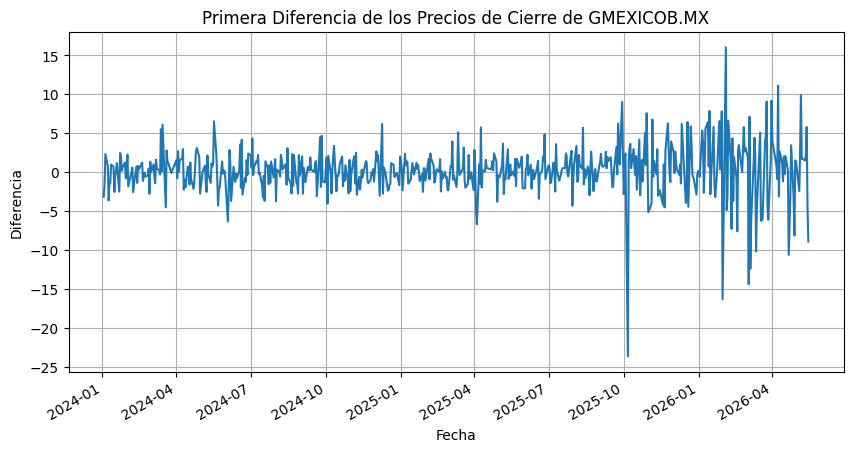

In [ ]:
# Visualizar la serie diferenciada
plt.figure(figsize=(10,5))
differenced_prices.plot()
plt.title(f'Primera Diferencia de los Precios de Cierre de {"GMEXICOB.MX"}')
plt.xlabel('Fecha')
plt.ylabel('Diferencia')
plt.grid(True)
plt.show()

In [ ]:
# Ejecutar prueba en serie diferenciada
probar_estacionariedad(differenced_prices, "Serie diferenciada")


--- Prueba ADF para: Serie diferenciada ---
Estadístico de Dickey-Fuller: -26.8263
Valor p: 0.0000
Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).


0.0